In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [19]:
df = pd.read_csv('/content/housing.csv', delim_whitespace=True, header=None)
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.columns = column_names
df.rename(columns={'RM': 'total_bedrooms', 'MEDV': 'median_house_value'}, inplace=True)

print("First 5 rows of the dataset:")
display(df.head())

print("\nInformation about the dataset:")
df.info()

First 5 rows of the dataset:


/tmp/ipykernel_3819/3664263100.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('/content/housing.csv', delim_whitespace=True, header=None)


,CRIM,ZN,INDUS,CHAS,NOX,total_bedrooms,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,median_house_value
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CRIM                506 non-null    float64
 1   ZN                  506 non-null    float64
 2   INDUS               506 non-null    float64
 3   CHAS                506 non-null    int64  
 4   NOX                 506 non-null    float64
 5   total_bedrooms      506 non-null    float64
 6   AGE                 506 non-null    float64
 7   DIS                 506 non-null    float64
 8   RAD                 506 non-null    int64  
 9   TAX                 506 non-null    float64
 10  PTRATIO             506 non-null    float64
 11  B                   506 non-null    float64
 12  LSTAT               506 non-null    float64
 13  median_house_value  506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [20]:
print("Missing values before imputation:")
display(df.isnull().sum())
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'].fillna(median_bedrooms, inplace=True)
print("\nMissing values after imputation:")
display(df.isnull().sum())

Missing values before imputation:


,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
total_bedrooms,0
AGE,0
DIS,0
RAD,0
TAX,0



Missing values after imputation:


/tmp/ipykernel_3819/2787369512.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(median_bedrooms, inplace=True)


,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
total_bedrooms,0
AGE,0
DIS,0
RAD,0
TAX,0


In [21]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']
nm = X.select_dtypes(include=np.number).columns.tolist()
cf= X.select_dtypes(include='object').columns.tolist()
print(f"Numerical features: {nm}")
print(f"Categorical features: {cf}")

Numerical features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'total_bedrooms', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Categorical features: []


In [22]:
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])
X_preprocessed = preprocessor.fit_transform(X)
if len(categorical_features) > 0:
    encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
else:
    encoded_feature_names = []
all_feature_names = numerical_features + list(encoded_feature_names)
X_preprocessed_df = pd.DataFrame(X_preprocessed, columns=all_feature_names)
print("Shape of preprocessed data:", X_preprocessed.shape)
display(X_preprocessed_df.head())

Shape of preprocessed data: (506, 13)


,CRIM,ZN,INDUS,CHAS,NOX,total_bedrooms,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,-0.419782,0.284830,-1.287909,-0.272599,-0.144217,0.413672,-0.120013,0.140214,-0.982843,-0.666608,-1.459000,0.441052,-1.075562
1,-0.417339,-0.487722,-0.593381,-0.272599,-0.740262,0.194274,0.367166,0.557160,-0.867883,-0.987329,-0.303094,0.441052,-0.492439
2,-0.417342,-0.487722,-0.593381,-0.272599,-0.740262,1.282714,-0.265812,0.557160,-0.867883,-0.987329,-0.303094,0.396427,-1.208727
3,-0.416750,-0.487722,-1.306878,-0.272599,-0.835284,1.016303,-0.809889,1.077737,-0.752922,-1.106115,0.113032,0.416163,-1.361517
4,-0.412482,-0.487722,-1.306878,-0.272599,-0.835284,1.228577,-0.511180,1.077737,-0.752922,-1.106115,0.113032,0.441052,-1.026501


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_preprocessed, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 404 samples
Test set size: 102 samples


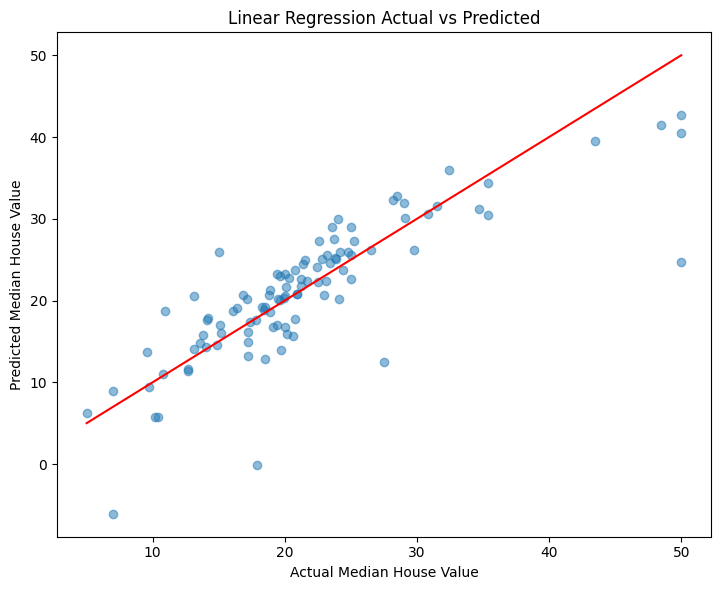

Linear Regression RMSE: 4.93
Linear Regression R-squared: 0.67


In [31]:
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)
y_pred_lr = linear_reg_model.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r')
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Linear Regression Actual vs Predicted")
plt.tight_layout()
plt.show()
print(f"Linear Regression RMSE: {rmse_lr:.2f}")
print(f"Linear Regression R-squared: {r2_lr:.2f}")

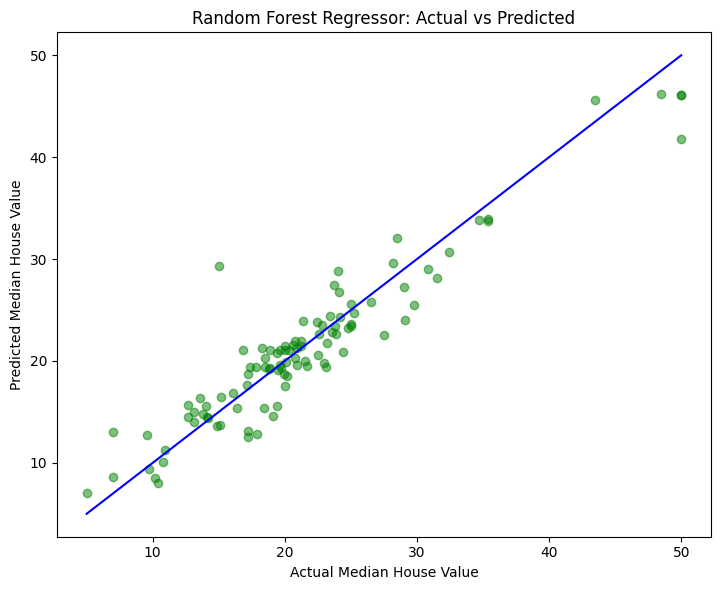

Random Forest Regressor RMSE: 2.82
Random Forest Regressor R-squared: 0.89


In [32]:
rf_reg_model = RandomForestRegressor(random_state=42)
rf_reg_model.fit(X_train, y_train)
y_pred_rf = rf_reg_model.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf, alpha=0.5, color = 'g')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b')
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Random Forest Regressor: Actual vs Predicted")

plt.tight_layout()
plt.show()
print(f"Random Forest Regressor RMSE: {rmse_rf:.2f}")
print(f"Random Forest Regressor R-squared: {r2_rf:.2f}")